## Preprocessing example

1. Load Data
2. Visualize data (EDA)
3. Clean data: remove columns and/or rows
4. X/y Split
5. train_test_split. (class only: if dataset is unbalanced, use stratify)
6. Fill/Encode/Scale Data: apply this only to the training set, then use those same parameters to transform the test set
7. Check Correlation Matrix on the scaled/encoded training data
8. Pick Model & Check Training Curve: Use the default settings on your training data (via Cross-Validation) to check for overfitting

(next steps omitted)

\9. Grid Search: find best hyperparameters using the training set (use cross validation or validation set)
\10. Train Final Model: Retrain the model on the entire training set using the best parameters found.
\11. View Results: use the test set to generate your Confusion Matrix, precision/recall/F1-score (class only), or R2, mse, mae (reg only)

---

In [1]:
# 1. Read CSV and load into dataframe

import pandas as pd

df = pd.read_csv("preprocess.csv")

df

,id,timestamp,temperature,humidity,city,device,target_class,energy_consumption
0,1,2024-03-26 15:00:00,30.406666,80.326630,Tokyo,Sensor_B,0,97.513592
1,2,2024-07-08 07:00:00,18.273757,69.068736,Tokyo,Sensor_B,0,59.528804
2,3,2024-08-02 23:00:00,28.666433,35.335695,London,Sensor_B,0,73.507854
3,4,2024-08-01 20:00:00,23.709832,65.580936,London,Sensor_B,0,81.858318
4,5,2024-06-10 06:00:00,21.934351,85.340882,London,Sensor_B,0,74.997384
...,...,...,...,...,...,...,...,...
495,496,2024-06-16 01:00:00,22.390849,59.565279,Paris,Sensor_B,0,68.260201
496,497,2024-01-14 15:00:00,26.149340,32.016226,Tokyo,Sensor_A,1,69.453723
497,498,2024-04-26 08:00:00,NaN,48.337483,Tokyo,Sensor_A,0,68.208705
498,499,2024-10-15 04:00:00,NaN,39.088035,Paris,Sensor_A,0,63.309870


C:\Users\VM\AppData\Local\Temp\ipykernel_22744\1925160718.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([num_df[col].dropna() for col in num_df.columns], labels=num_df.columns)


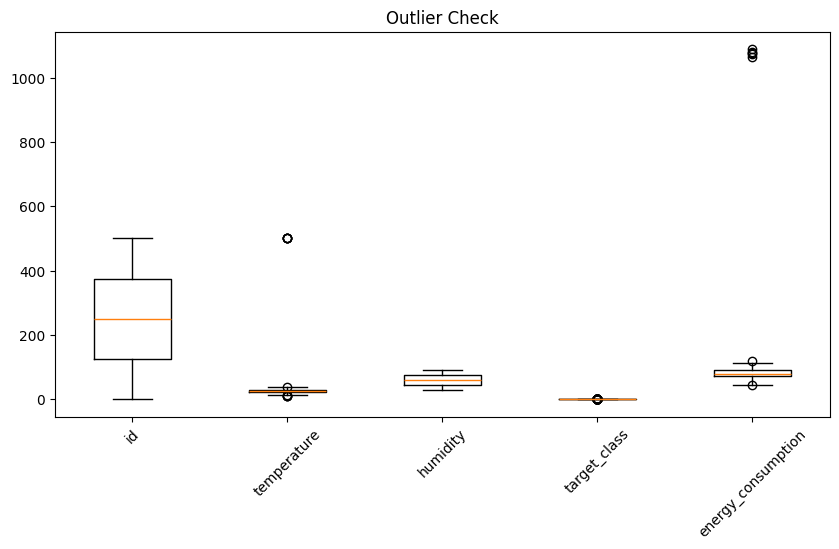

In [5]:
# 2. Analyze dataset with charts (Matplotlib)

import numpy as np
import matplotlib.pyplot as plt

def check_outliers(df):
    num_df = df.select_dtypes(include=[np.number])
    plt.figure(figsize=(10, 5))
    plt.boxplot([num_df[col].dropna() for col in num_df.columns], labels=num_df.columns)
    plt.title("Outlier Check")
    plt.xticks(rotation=45)
    plt.show()

check_outliers(df)

In [6]:
# 3. Feature Engineering: Hour and Cyclic Encoding

df_encoded = df.copy()
df_encoded["timestamp"] = pd.to_datetime(df_encoded["timestamp"])
df_encoded["hour"] = df_encoded["timestamp"].dt.hour
df_encoded["hour_sin"] = np.sin(2 * np.pi * df_encoded["hour"] / 24)
df_encoded["hour_cos"] = np.cos(2 * np.pi * df_encoded["hour"] / 24)

df_encoded

,id,timestamp,temperature,humidity,city,device,target_class,energy_consumption,hour,hour_sin,hour_cos
0,1,2024-03-26 15:00:00,30.406666,80.326630,Tokyo,Sensor_B,0,97.513592,15,-0.707107,-7.071068e-01
1,2,2024-07-08 07:00:00,18.273757,69.068736,Tokyo,Sensor_B,0,59.528804,7,0.965926,-2.588190e-01
2,3,2024-08-02 23:00:00,28.666433,35.335695,London,Sensor_B,0,73.507854,23,-0.258819,9.659258e-01
3,4,2024-08-01 20:00:00,23.709832,65.580936,London,Sensor_B,0,81.858318,20,-0.866025,5.000000e-01
4,5,2024-06-10 06:00:00,21.934351,85.340882,London,Sensor_B,0,74.997384,6,1.000000,6.123234e-17
...,...,...,...,...,...,...,...,...,...,...,...
495,496,2024-06-16 01:00:00,22.390849,59.565279,Paris,Sensor_B,0,68.260201,1,0.258819,9.659258e-01
496,497,2024-01-14 15:00:00,26.149340,32.016226,Tokyo,Sensor_A,1,69.453723,15,-0.707107,-7.071068e-01
497,498,2024-04-26 08:00:00,NaN,48.337483,Tokyo,Sensor_A,0,68.208705,8,0.866025,-5.000000e-01
498,499,2024-10-15 04:00:00,NaN,39.088035,Paris,Sensor_A,0,63.309870,4,0.866025,5.000000e-01


In [7]:
df_clean = df_encoded.copy()

# 4. Remove unnecessary columns
df_clean = df_clean.drop(columns=["id", "timestamp", "hour"], errors="ignore")

# 5. Remove certain rows if too many variables are missing
# Drop rows with more than 30% missing data
df_clean = df_clean.dropna(thresh=int(df.shape[1] * 0.7))

df_clean

,temperature,humidity,city,device,target_class,energy_consumption,hour_sin,hour_cos
0,30.406666,80.326630,Tokyo,Sensor_B,0,97.513592,-0.707107,-7.071068e-01
1,18.273757,69.068736,Tokyo,Sensor_B,0,59.528804,0.965926,-2.588190e-01
2,28.666433,35.335695,London,Sensor_B,0,73.507854,-0.258819,9.659258e-01
3,23.709832,65.580936,London,Sensor_B,0,81.858318,-0.866025,5.000000e-01
4,21.934351,85.340882,London,Sensor_B,0,74.997384,1.000000,6.123234e-17
...,...,...,...,...,...,...,...,...
495,22.390849,59.565279,Paris,Sensor_B,0,68.260201,0.258819,9.659258e-01
496,26.149340,32.016226,Tokyo,Sensor_A,1,69.453723,-0.707107,-7.071068e-01
497,NaN,48.337483,Tokyo,Sensor_A,0,68.208705,0.866025,-5.000000e-01
498,NaN,39.088035,Paris,Sensor_A,0,63.309870,0.866025,5.000000e-01


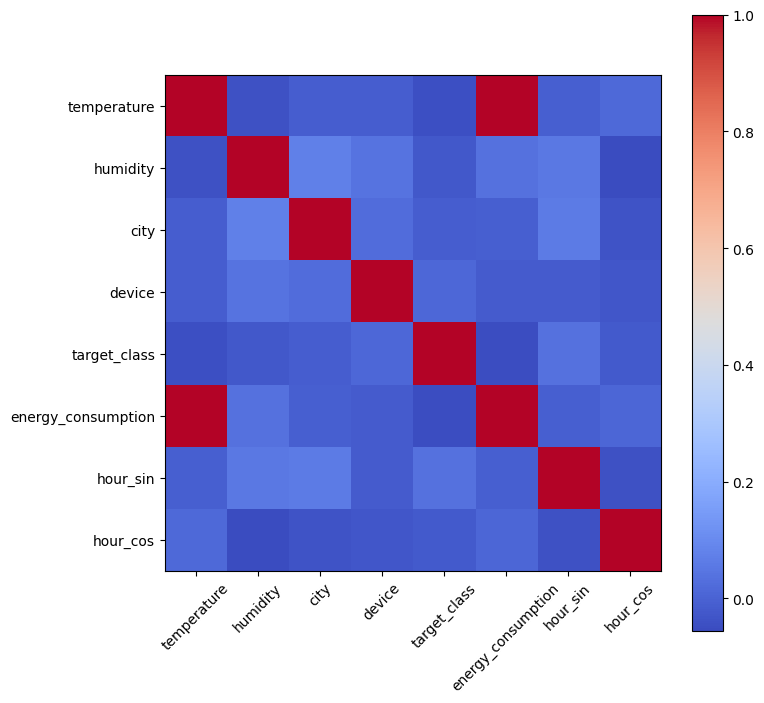

In [8]:
# 6. Check correlation matrix ("Rough" encoding on copy)
df_temp = df_clean.copy()
for col in df_temp.select_dtypes(include=["object"]).columns:
    df_temp[col] = df_temp[col].astype("category").cat.codes

corr = df_temp.corr()
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(corr, cmap="coolwarm")
plt.colorbar(im)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticklabels(corr.columns)
plt.show()

In [9]:
# 7. Split X and y

target = "target_class"
X = df_clean.drop(columns=[target])
y = df_clean[target]

X, y

(     temperature   humidity    city    device  energy_consumption  hour_sin  \
 0      30.406666  80.326630   Tokyo  Sensor_B           97.513592 -0.707107   
 1      18.273757  69.068736   Tokyo  Sensor_B           59.528804  0.965926   
 2      28.666433  35.335695  London  Sensor_B           73.507854 -0.258819   
 3      23.709832  65.580936  London  Sensor_B           81.858318 -0.866025   
 4      21.934351  85.340882  London  Sensor_B           74.997384  1.000000   
 ..           ...        ...     ...       ...                 ...       ...   
 495    22.390849  59.565279   Paris  Sensor_B           68.260201  0.258819   
 496    26.149340  32.016226   Tokyo  Sensor_A           69.453723 -0.707107   
 497          NaN  48.337483   Tokyo  Sensor_A           68.208705  0.866025   
 498          NaN  39.088035   Paris  Sensor_A           63.309870  0.866025   
 499    22.889494  87.189936   Paris  Sensor_A           87.784767  0.500000   
 
          hour_cos  
 0   -7.071068e-0

In [10]:
# 8. Split X and y into train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2,
    stratify=y, # classification only
)

X_train, X_test

(     temperature   humidity      city    device  energy_consumption  \
 335          NaN  82.630928  New York  Sensor_B           96.218133   
 412    20.008739  72.282347    London  Sensor_A           66.708066   
 4      21.934351  85.340882    London  Sensor_B           74.997384   
 176    26.746841  88.542781     Paris  Sensor_A          102.702056   
 54     36.800116  83.618839     Paris  Sensor_A          108.783374   
 ..           ...        ...       ...       ...                 ...   
 398    23.659894  82.678481    London  Sensor_B           84.429202   
 445          NaN  39.104855     Tokyo  Sensor_B           70.242640   
 185    30.750338  52.240295     Paris  Sensor_A           87.044302   
 64     28.378376  74.460420     Paris  Sensor_B           89.944673   
 210    36.392033  58.340760    London  Sensor_B          110.537998   
 
          hour_sin      hour_cos  
 335  8.660254e-01 -5.000000e-01  
 412 -7.071068e-01  7.071068e-01  
 4    1.000000e+00  6.123234e

In [11]:
# 9. Fill in missing values

numerical_cols = X_train.select_dtypes(include=[np.number]).columns
category_cols = X_train.select_dtypes(include=["object"]).columns

# Fit on train
train_medians = X_train[numerical_cols].median()
train_modes = X_train[category_cols].mode().iloc[0]

# Transform train and test
X_train[numerical_cols] = X_train[numerical_cols].fillna(train_medians)
X_test[numerical_cols] = X_test[numerical_cols].fillna(train_medians)
X_train[category_cols] = X_train[category_cols].fillna(train_modes)
X_test[category_cols] = X_test[category_cols].fillna(train_modes)

X_train, X_test

(     temperature   humidity      city    device  energy_consumption  \
 335    25.421852  82.630928  New York  Sensor_B           96.218133   
 412    20.008739  72.282347    London  Sensor_A           66.708066   
 4      21.934351  85.340882    London  Sensor_B           74.997384   
 176    26.746841  88.542781     Paris  Sensor_A          102.702056   
 54     36.800116  83.618839     Paris  Sensor_A          108.783374   
 ..           ...        ...       ...       ...                 ...   
 398    23.659894  82.678481    London  Sensor_B           84.429202   
 445    25.421852  39.104855     Tokyo  Sensor_B           70.242640   
 185    30.750338  52.240295     Paris  Sensor_A           87.044302   
 64     28.378376  74.460420     Paris  Sensor_B           89.944673   
 210    36.392033  58.340760    London  Sensor_B          110.537998   
 
          hour_sin      hour_cos  
 335  8.660254e-01 -5.000000e-01  
 412 -7.071068e-01  7.071068e-01  
 4    1.000000e+00  6.123234e

In [12]:
from sklearn.preprocessing import OneHotEncoder

# 10. Encode text columns with OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_ohe = pd.DataFrame(
    encoder.fit_transform(X_train[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index,
)
X_test_ohe = pd.DataFrame(
    encoder.transform(X_test[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index,
)

X_train_final = pd.concat([X_train[num_cols], X_train_ohe], axis=1)
X_test_final = pd.concat([X_test[num_cols], X_test_ohe], axis=1)

NameError: name 'cat_cols' is not defined

In [ ]:
# 11. Standard Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

In [ ]:
# Preprocess complete

# Train the model and score results (omitted)